# Phase 5 (v4) — SOH Estimation: CNN-BiLSTM-Attention

**Fixes from v3:**
1. **Stratified split** (per-battery, by SOH bin) instead of purely chronological —
   so both train and test cover fresh / mid-life / aged cycles from every battery.
2. **SOH normalized to [0,1]** during training; predictions rescaled back for metrics.
3. StandardScaler on signals as before (fit on real train only).

**Three stages — all tested on the same stratified held-out real test cycles:**
- Stage 1: Real-only baseline
- Stage 2: TSTR (Train on Synthetic, Test on Real)
- Stage 3: Augmented (Real + Synthetic)

**Metrics:** RMSE (%), MAE (%), MSE, R²


In [1]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
print("GPU:", tf.config.list_physical_devices("GPU"))

PHASE2_DIR  = "/kaggle/input/datasets/tasniaturin12/nasa-gaf-phase2-output"
PHASE3_DIR  = "/kaggle/input/datasets/tasniaturin12/nasa-gaf-phase3-output"
OUTPUT_DIR  = "/kaggle/working"
NOISE_DIM   = 100
NUM_CLASSES = 3
TARGET_LEN  = 128

images_array = np.load(os.path.join(PHASE2_DIR, "nasa_gaf_images.npz"))["images"]
with open(os.path.join(PHASE2_DIR, "nasa_gaf_minmax.pkl"), "rb") as f:
    gaf_minmax = pickle.load(f)
labels_df = pd.read_csv(os.path.join(PHASE2_DIR, "nasa_gaf_labels.csv"))
generator = tf.keras.models.load_model(os.path.join(PHASE3_DIR, "cwdcgan_generator.keras"))

print("Images:", images_array.shape)
labels_df.head()


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


I0000 00:00:1789061261.350266      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789061261.353196      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Images: (2544, 128, 128, 3)


,battery_id,source_cycle,SOH_percent,is_augmented
0,B0005,0,92.824371,False
1,B0005,0,92.824371,True
2,B0005,0,92.824371,True
3,B0005,0,92.824371,True
4,B0005,1,92.316362,False


## 2. Stratified Train/Test Split

Split **per battery, per SOH bin** so that train and test each contain early/mid/late
degradation cycles from every battery. Test fraction = 20%.
Only real (non-augmented) cycles participate in this split.


In [2]:
def soh_to_bin(soh):
    if soh >= 85:   return 0   # fresh
    elif soh >= 70: return 1   # mid-life
    else:           return 2   # aged

BIN_NAMES = {0: "fresh", 1: "mid-life", 2: "aged"}
TEST_FRAC  = 0.20

# Work only with non-augmented (real) rows
real_df = labels_df[~labels_df["is_augmented"]].copy().reset_index(drop=True)
real_df["soh_bin"] = real_df["SOH_percent"].apply(soh_to_bin)

# Stratify by battery_id + soh_bin combined label
real_df["strat_key"] = real_df["battery_id"] + "_" + real_df["soh_bin"].astype(str)

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=42)
train_idx, test_idx = next(sss.split(real_df, real_df["strat_key"]))

train_df = real_df.iloc[train_idx].copy()
test_df  = real_df.iloc[test_idx].copy()

print(f"Train: {len(train_df)} cycles | Test: {len(test_df)} cycles")
print("\nTrain SOH bin distribution:")
print(train_df["soh_bin"].map(BIN_NAMES).value_counts())
print("\nTest SOH bin distribution:")
print(test_df["soh_bin"].map(BIN_NAMES).value_counts())
print(f"\nTrain SOH range: {train_df['SOH_percent'].min():.1f}% – {train_df['SOH_percent'].max():.1f}%")
print(f"Test  SOH range: {test_df['SOH_percent'].min():.1f}% – {test_df['SOH_percent'].max():.1f}%")


Train: 508 cycles | Test: 128 cycles

Train SOH bin distribution:
soh_bin
mid-life    238
fresh       165
aged        105
Name: count, dtype: int64

Test SOH bin distribution:
soh_bin
mid-life    60
fresh       42
aged        26
Name: count, dtype: int64

Train SOH range: 57.7% – 101.8%
Test  SOH range: 57.9% – 100.7%


## 3. Inverse-GAF → Raw Signals (Per-Cycle Exact Min/Max)

In [3]:
def inverse_gasf_diag(image_channel, min_val, max_val):
    diag   = np.clip(np.diag(image_channel), -1.0, 1.0)
    phi    = 0.5 * np.arccos(diag)
    scaled = np.cos(phi)
    return scaled * (max_val - min_val) + min_val

def image_to_signals(image, minmax):
    v = inverse_gasf_diag(image[:, :, 0], *minmax["voltage"])
    i = inverse_gasf_diag(image[:, :, 1], *minmax["current"])
    t = inverse_gasf_diag(image[:, :, 2], *minmax["temperature"])
    return np.stack([v, i, t], axis=-1)  # [128, 3]

def build_signal_set(df, images_arr, gaf_minmax):
    X, y = [], []
    # df may have been reset_index'd — original image index is in "index" col if present,
    # otherwise use the df index directly against labels_df ordering
    for pos, row in enumerate(df.itertuples()):
        # locate the original row position in images_array via labels_df
        orig_idx = int(row.Index) if hasattr(row, 'Index') else pos
        # find the matching row in labels_df by battery_id + source_cycle + is_augmented=False
        match = labels_df[
            (labels_df["battery_id"]   == row.battery_id) &
            (labels_df["source_cycle"] == row.source_cycle) &
            (~labels_df["is_augmented"])
        ]
        if len(match) == 0:
            continue
        img_idx = match.index[0]
        img     = images_arr[img_idx]
        battery = row.battery_id
        cycle   = int(row.source_cycle)
        if battery in gaf_minmax and cycle in gaf_minmax[battery]:
            minmax = gaf_minmax[battery][cycle]
        else:
            minmax = next(iter(gaf_minmax[battery].values()))
        X.append(image_to_signals(img, minmax))
        y.append(row.SOH_percent)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Building train signals...")
X_real_train, y_real_train = build_signal_set(train_df, images_array, gaf_minmax)
print("Building test signals...")
X_real_test,  y_test       = build_signal_set(test_df,  images_array, gaf_minmax)

print(f"\nReal train: {X_real_train.shape} | Test: {X_real_test.shape}")
print(f"Train SOH: {y_real_train.min():.1f}% – {y_real_train.max():.1f}%")
print(f"Test  SOH: {y_test.min():.1f}% – {y_test.max():.1f}%")


Building train signals...
Building test signals...

Real train: (508, 128, 3) | Test: (128, 128, 3)
Train SOH: 57.7% – 101.8%
Test  SOH: 57.9% – 100.7%


## 4. Generate Synthetic Signals

In [4]:
global_minmax = {
    "voltage":     (float(X_real_train[:,:,0].min()), float(X_real_train[:,:,0].max())),
    "current":     (float(X_real_train[:,:,1].min()), float(X_real_train[:,:,1].max())),
    "temperature": (float(X_real_train[:,:,2].min()), float(X_real_train[:,:,2].max())),
}

def generate_synthetic(generator, soh_targets, noise_dim=NOISE_DIM):
    X_syn = []
    for soh in soh_targets:
        bin_id = soh_to_bin(float(soh))
        noise  = tf.random.normal([1, noise_dim])
        label  = tf.constant([[bin_id]])
        img    = generator([noise, label], training=False).numpy()[0]
        X_syn.append(image_to_signals(img, global_minmax))
    return np.array(X_syn, dtype=np.float32)

N_SYN = len(X_real_train)
soh_targets = np.random.choice(y_real_train, size=N_SYN, replace=True)
print(f"Generating {N_SYN} synthetic signals...")
X_syn = generate_synthetic(generator, soh_targets)
y_syn = soh_targets.astype(np.float32)
print(f"Synthetic: {X_syn.shape} | SOH: {y_syn.min():.1f}% – {y_syn.max():.1f}%")


Generating 508 synthetic signals...
Synthetic: (508, 128, 3) | SOH: 58.2% – 101.8%


## 5. Normalize Signals + SOH Labels

- **Signals:** StandardScaler (fit on real train, apply to all).
- **SOH labels:** Min-Max to [0,1] using train range (fit on real train, apply to all).
  Predictions are rescaled back to % for final metrics.


In [5]:
# Signal normalization
sig_scaler = StandardScaler()
n_tr  = len(X_real_train)
n_syn = len(X_syn)
n_te  = len(X_real_test)

sig_scaler.fit(X_real_train.reshape(n_tr, -1))

X_tr_sc  = sig_scaler.transform(X_real_train.reshape(n_tr,  -1)).reshape(n_tr,  TARGET_LEN, 3).astype(np.float32)
X_syn_sc = sig_scaler.transform(X_syn.reshape(n_syn, -1)).reshape(n_syn, TARGET_LEN, 3).astype(np.float32)
X_te_sc  = sig_scaler.transform(X_real_test.reshape(n_te,  -1)).reshape(n_te,  TARGET_LEN, 3).astype(np.float32)

X_aug_sc = np.concatenate([X_tr_sc, X_syn_sc], axis=0)

# SOH normalization to [0,1]
soh_min = float(y_real_train.min())
soh_max = float(y_real_train.max())

def norm_soh(y):  return (y - soh_min) / (soh_max - soh_min)
def denorm_soh(y_n): return y_n * (soh_max - soh_min) + soh_min

y_tr_n   = norm_soh(y_real_train)
y_syn_n  = norm_soh(y_syn)
y_aug_n  = np.concatenate([y_tr_n, y_syn_n])
# Test labels kept in % for final metrics

print(f"Train: {X_tr_sc.shape} | Syn: {X_syn_sc.shape} | Test: {X_te_sc.shape} | Aug: {X_aug_sc.shape}")
print(f"SOH norm range (train): {y_tr_n.min():.3f} – {y_tr_n.max():.3f}")


Train: (508, 128, 3) | Syn: (508, 128, 3) | Test: (128, 128, 3) | Aug: (1016, 128, 3)
SOH norm range (train): 0.000 – 1.000


## 6. CNN-BiLSTM-Attention Model

In [6]:
def attention_block(x):
    score   = layers.Dense(1, activation="tanh")(x)
    weight  = layers.Softmax(axis=1)(score)
    context = layers.Multiply()([x, weight])
    return layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(context)

def build_model(input_shape=(TARGET_LEN, 3)):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(64,  3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)
    x = attention_block(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)  # [0,1] output matches normalized SOH
    model = Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return model

build_model().summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 64)   │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 128)  │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 64, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 128)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 64, 128)   │     98,816 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64, 64)    │     41,216 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64, 1)     │         65 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 64, 1)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64, 64)    │          0 │ bidirectional_1[… │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 170,434 (665.76 KB)

 Trainable params: 170,050 (664.26 KB)

 Non-trainable params: 384 (1.50 KB)

## 7. Training & Evaluation

In [7]:
EPOCHS = 150
BATCH  = 32

def train_evaluate(X_tr, y_tr_norm, name):
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"  Train: {X_tr.shape} | Test: {X_te_sc.shape}")
    print('='*55)
    model = build_model()
    cb = [
        callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6),
    ]
    hist = model.fit(X_tr, y_tr_norm,
                     validation_split=0.15,
                     epochs=EPOCHS, batch_size=BATCH,
                     callbacks=cb, verbose=0)

    # Predict and denormalize back to %
    pred_norm = model.predict(X_te_sc, verbose=0).flatten()
    pred      = denorm_soh(pred_norm)

    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    mae  = float(mean_absolute_error(y_test, pred))
    mse  = float(mean_squared_error(y_test, pred))
    r2   = float(r2_score(y_test, pred))
    print(f"  RMSE={rmse:.4f}%  MAE={mae:.4f}%  MSE={mse:.4f}  R²={r2:.4f}")
    return model, hist, pred, {"Stage": name,
                                "RMSE (%)": round(rmse,4),
                                "MAE (%)":  round(mae,4),
                                "MSE":      round(mse,4),
                                "R2":       round(r2,4)}


## 8. Stage 1 — Real-Only Baseline

In [8]:
m1, h1, p1, met1 = train_evaluate(X_tr_sc, y_tr_n, "Stage 1: Real-only")


  Stage 1: Real-only
  Train: (508, 128, 3) | Test: (128, 128, 3)
  RMSE=0.7959%  MAE=0.6056%  MSE=0.6334  R²=0.9934


## 9. Stage 2 — TSTR (Train on Synthetic, Test on Real)

In [9]:
m2, h2, p2, met2 = train_evaluate(X_syn_sc, y_syn_n, "Stage 2: TSTR (Synthetic only)")


  Stage 2: TSTR (Synthetic only)
  Train: (508, 128, 3) | Test: (128, 128, 3)
  RMSE=16.8851%  MAE=14.0189%  MSE=285.1071  R²=-1.9597


## 10. Stage 3 — Augmented (Real + Synthetic)

In [10]:
m3, h3, p3, met3 = train_evaluate(X_aug_sc, y_aug_n, "Stage 3: Augmented (Real + Synthetic)")


  Stage 3: Augmented (Real + Synthetic)
  Train: (1016, 128, 3) | Test: (128, 128, 3)
  RMSE=0.9631%  MAE=0.7333%  MSE=0.9275  R²=0.9904


## 11. Training Curves

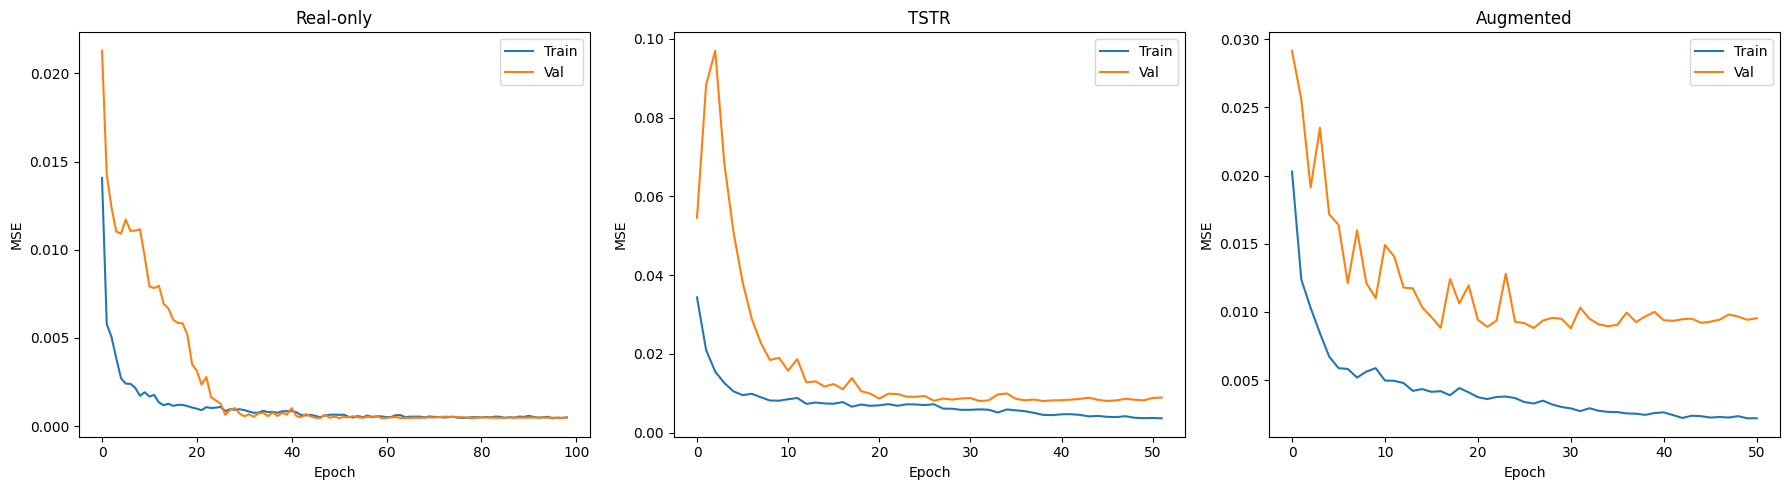

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, h, name in zip(axes, [h1, h2, h3], ["Real-only", "TSTR", "Augmented"]):
    ax.plot(h.history["loss"], label="Train")
    ax.plot(h.history["val_loss"], label="Val")
    ax.set_title(name); ax.set_xlabel("Epoch"); ax.set_ylabel("MSE"); ax.legend()
plt.tight_layout(); plt.show()


## 12. True vs Predicted SOH

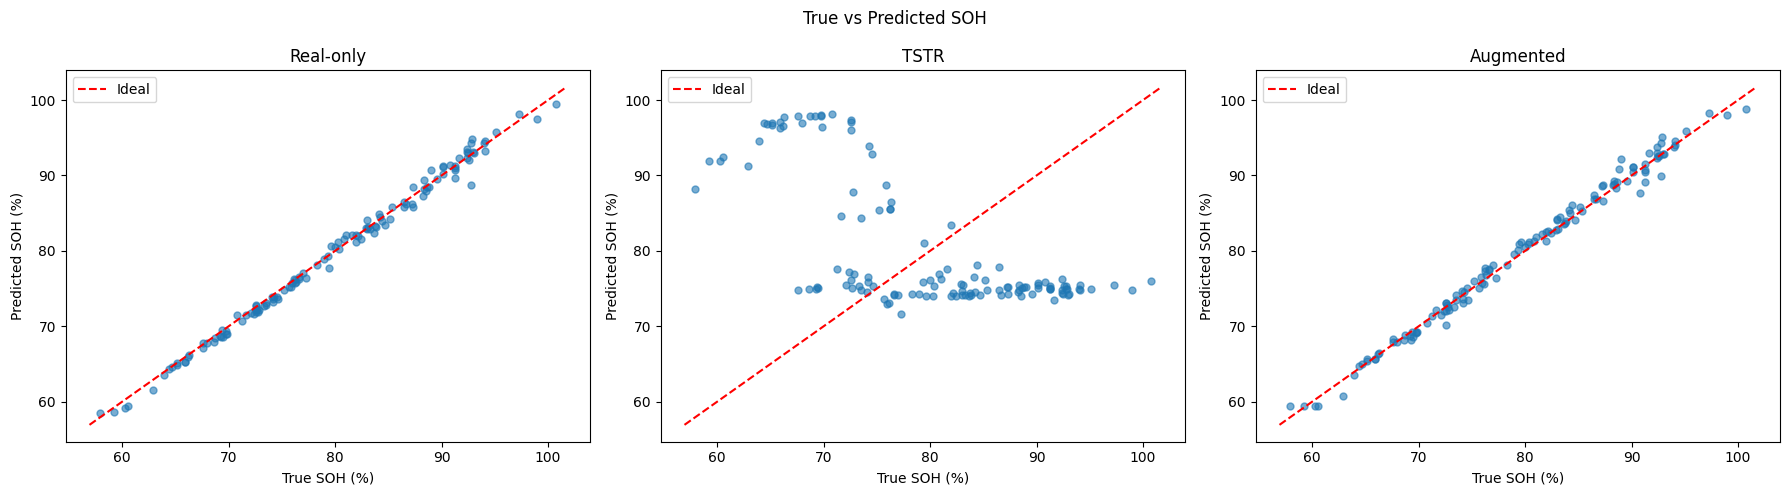

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pred, name in zip(axes, [p1, p2, p3], ["Real-only", "TSTR", "Augmented"]):
    ax.scatter(y_test, pred, alpha=0.6, s=25)
    lim = [min(y_test.min(), pred.min())-1, max(y_test.max(), pred.max())+1]
    ax.plot(lim, lim, "r--", label="Ideal")
    ax.set_xlabel("True SOH (%)"); ax.set_ylabel("Predicted SOH (%)")
    ax.set_title(name); ax.legend()
plt.suptitle("True vs Predicted SOH"); plt.tight_layout(); plt.show()


## 13. Results Summary

In [13]:
results_df = pd.DataFrame([met1, met2, met3])
print(results_df.to_string(index=False))
results_df.to_csv(os.path.join(OUTPUT_DIR, "phase5_soh_results.csv"), index=False)
print("\nSaved: phase5_soh_results.csv")
print("Phase 5 complete.")


                                Stage  RMSE (%)  MAE (%)      MSE      R2
                   Stage 1: Real-only    0.7959   0.6056   0.6334  0.9934
       Stage 2: TSTR (Synthetic only)   16.8851  14.0189 285.1071 -1.9597
Stage 3: Augmented (Real + Synthetic)    0.9631   0.7333   0.9275  0.9904

Saved: phase5_soh_results.csv
Phase 5 complete.


In [14]:
import numpy as np

# Training histories
np.save('/kaggle/working/h1_loss.npy', np.array(h1.history['loss']))
np.save('/kaggle/working/h1_val.npy',  np.array(h1.history['val_loss']))
np.save('/kaggle/working/h2_loss.npy', np.array(h2.history['loss']))
np.save('/kaggle/working/h2_val.npy',  np.array(h2.history['val_loss']))
np.save('/kaggle/working/h3_loss.npy', np.array(h3.history['loss']))
np.save('/kaggle/working/h3_val.npy',  np.array(h3.history['val_loss']))

# Prediction data
np.save('/kaggle/working/y_test.npy', y_test)
np.save('/kaggle/working/p1.npy', p1)
np.save('/kaggle/working/p2.npy', p2)
np.save('/kaggle/working/p3.npy', p3)

print("y_test:", y_test.shape)
print("p1:", p1.shape)
print("h1 epochs:", len(h1.history['loss']))

y_test: (128,)
p1: (128,)
h1 epochs: 99
